# RR Array：多模态瑞利波分离与三台干涉去噪

## 1. 案例目标

高频背景噪声互相关函数（ambient-noise cross-correlation，ANC）通常具有较低的信噪比。在线性密集台阵中，三台干涉（three-station interferometry，TSI）可以利用直达面波在不同台站组合中稳定的几何走时关系增强目标信号，同时压制随机噪声、散射波和其他非相干成分。

但是，TSI 本身不能自动区分不同面波模态。当基阶与高阶瑞利波在相同频带内共存且能量接近、或不同模态在不同台间距的互相关函数中分别占主导时，干涉计算会产生模态交叉项，去噪结果不再对应单一、明确的面波模态。因此，本案例遵循一条核心原则：

> **先根据极化特征和相速度差异分离模态，再对各模态分别进行三台干涉去噪。**
本教程按以下顺序组织：四分量 ANC 预处理 → MASW 识别频散能量 → 极化分离 → 参考曲线相位匹配 → M0/M1 分别进行 TSI 诊断和迭代去噪。每一步的文本摘要用于确认数据几何和计算状态。

## 2. 研究区与数据

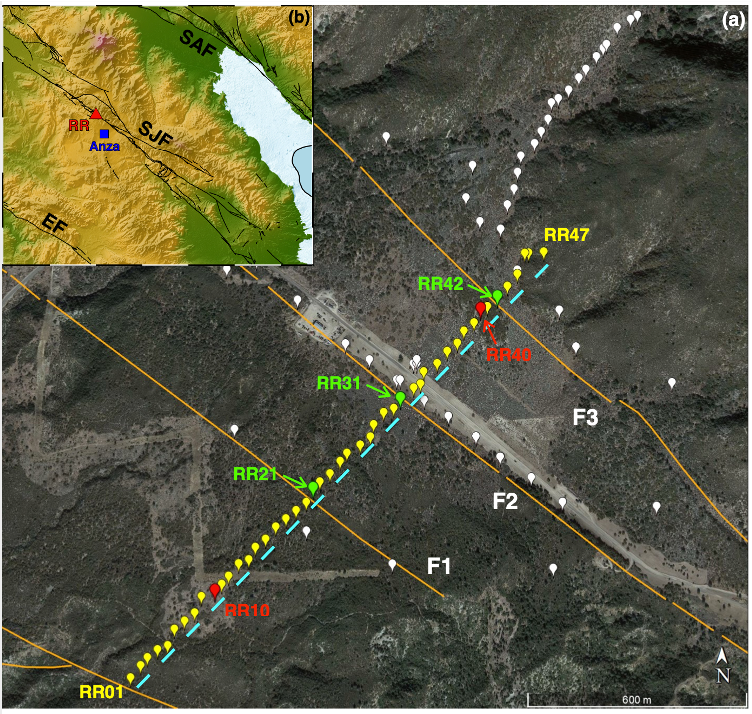

Ramona Reservation（RR）密集台阵位于美国南加州 Anza 地区，横跨 San Jacinto 断裂带 Clark 分支附近的多条地表断层迹线。完整台阵由 94 个三分量 5 Hz Fairfield 节点地震仪组成，连续记录时间约一个月。

本案例使用 RR01-RR47 子阵列。该子阵列：

- 近似沿一条直线排列；
- 平均台间距约 30 m；
- 阵列孔径约 1.6 km；
- 包含 ZZ、ZR、RZ 和 RR 四个与瑞利波相关的 ANC 分量；
- 同时发育基阶、第一高阶和更高阶瑞利波。
这里的 `input_public/` 是为公开教学准备的均匀抽样输入；台站名保持原始命名。缓存写入本案例目录下的 `processed/`，因此重复运行时可以跳过耗时的读取、MASW 和去噪计算。

## 3. Step 0：导入程序并设置路径及默认参数
本步骤固定数据目录、四个 ANC 分量、频带、速度范围和代表性台站对。距离单位为 km，时间单位为 s，频率单位为 Hz，相速度单位为 km/s。

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from tsi_denoising import (
    Wavefield,
    MASW,
    DenoisingResult, 
    read_sac_directory,
    phase_match_separate,
    polarization_separate,
    denoise_station_pair_demo,
    denoise_wavefield_iteratively,
    plot_denoised_result
)

def print_wavefield_summary(label, wavefield, cache_status):
    """Print compact geometry and sampling metadata for a Wavefield."""
    stations = sorted({station for pair in wavefield.pairs for station in pair})
    distance = wavefield.distances
    time = wavefield.time
    station_range = f"{stations[0]}-{stations[-1]}" if stations else "<empty>"
    print(
        f"[{label}] {cache_status}; pairs={wavefield.n_pairs}, "
        f"stations={len(stations)} ({station_range}), samples={wavefield.n_samples}"
    )
    print(
        f"  sampling: delta={wavefield.delta:.6f} s, rate={wavefield.sampling_rate:.3f} Hz; "
        f"time={time[0]:.3f}..{time[-1]:.3f} s"
    )
    print(f"  distances: {distance.min():.4f}..{distance.max():.4f} km")

def print_masw_summary(label, masw):
    """Print the computed MASW grid and its strongest image sample."""
    peak_index = np.unravel_index(np.nanargmax(masw.amplitude), masw.amplitude.shape)
    print(
        f"[{label}] grid={masw.amplitude.shape}; "
        f"frequency={masw.frequency[0]:.3f}..{masw.frequency[-1]:.3f} Hz; "
        f"velocity={masw.velocity[0]:.3f}..{masw.velocity[-1]:.3f} km/s"
    )
    print(
        f"  strongest normalized energy: f={masw.frequency[peak_index[0]]:.3f} Hz, "
        f"v={masw.velocity[peak_index[1]]:.3f} km/s"
    )

def print_denoising_summary(label, result):
    """Print convergence diagnostics returned by iterative TSI."""
    changes = np.array2string(result.relative_changes, precision=4, separator=", ")
    print(
        f"[{label}] iterations={result.iterations}, converged={result.converged}, "
        f"stop_reason={result.stop_reason}"
    )
    print(f"  relative changes: {changes}")

def print_reference_curve_summary(label, curve):
    """Print the frequency and velocity span of a reference curve."""
    values = np.asarray(curve, dtype=float)
    print(
        f"[{label}] points={len(values)}; "
        f"frequency={values[:, 0].min():.3f}..{values[:, 0].max():.3f} Hz; "
        f"velocity={values[:, 1].min():.3f}..{values[:, 1].max():.3f} km/s"
    )

CASE_DIR = Path("./")
SAC_DIR = CASE_DIR / "input_public"
PROCESSED_DIR = CASE_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

if not SAC_DIR.is_dir():
    raise FileNotFoundError(
        f"输入数据目录不存在：{SAC_DIR.resolve()}\n"
        "请先在项目根目录运行 `python retrieve_datasets.py` 下载教学数据。"
    )

print(f"输入数据目录：{SAC_DIR}")
print(f"缓存目录：{PROCESSED_DIR}")


COMPONENTS = ("ZZ", "ZR", "RZ", "RR")  # 四个与 Rayleigh 波相关的 ANC 分量。
FMIN = 0.5; FMAX = 5.0  # 分析频带，单位 Hz。
VMIN = 0.1; VMAX = 2.5  # 速度窗边界，单位 km/s。
EXAMPLE_PAIR = ("010", "040")  # 保留的虚拟源/接收示例台站对。
EXAMPLE_PERIODS = (0.8, 0.3)  # 诊断图中心周期，单位 s。
print(f"参数：components={COMPONENTS}, frequency={FMIN}-{FMAX} Hz, velocity={VMIN}-{VMAX} km/s")

输入数据目录：input_public
缓存目录：processed
参数：components=('ZZ', 'ZR', 'RZ', 'RR'), frequency=0.5-5.0 Hz, velocity=0.1-2.5 km/s


## 4. Step 1：读取并预处理四分量 ANC

`Wavefield.preprocess()` 依次完成：

1. 正负时间分支对称化；
2. 按 `distance / VMAX` 至 `distance / VMIN` 设置因果面波窗；
3. 在速度窗边界施加锥形过渡；
4. 进行 0.5-5.0 Hz 零相位带通滤波。

四个分量必须共享相同的台站对、采样间隔和距离元数据；后续极化组合才有明确的物理含义。

[RR Array / ZZ] read and preprocessed; pairs=253, stations=23 (001-047), samples=4001
  sampling: delta=0.020000 s, rate=50.000 Hz; time=-40.000..40.000 s
  distances: 0.0273..1.6200 km
[RR Array / ZR] read and preprocessed; pairs=253, stations=23 (001-047), samples=4001
  sampling: delta=0.020000 s, rate=50.000 Hz; time=-40.000..40.000 s
  distances: 0.0273..1.6200 km
[RR Array / RZ] read and preprocessed; pairs=253, stations=23 (001-047), samples=4001
  sampling: delta=0.020000 s, rate=50.000 Hz; time=-40.000..40.000 s
  distances: 0.0273..1.6200 km
[RR Array / RR] read and preprocessed; pairs=253, stations=23 (001-047), samples=4001
  sampling: delta=0.020000 s, rate=50.000 Hz; time=-40.000..40.000 s
  distances: 0.0273..1.6200 km
四个 ANC 分量的台站对、采样和距离元数据一致。


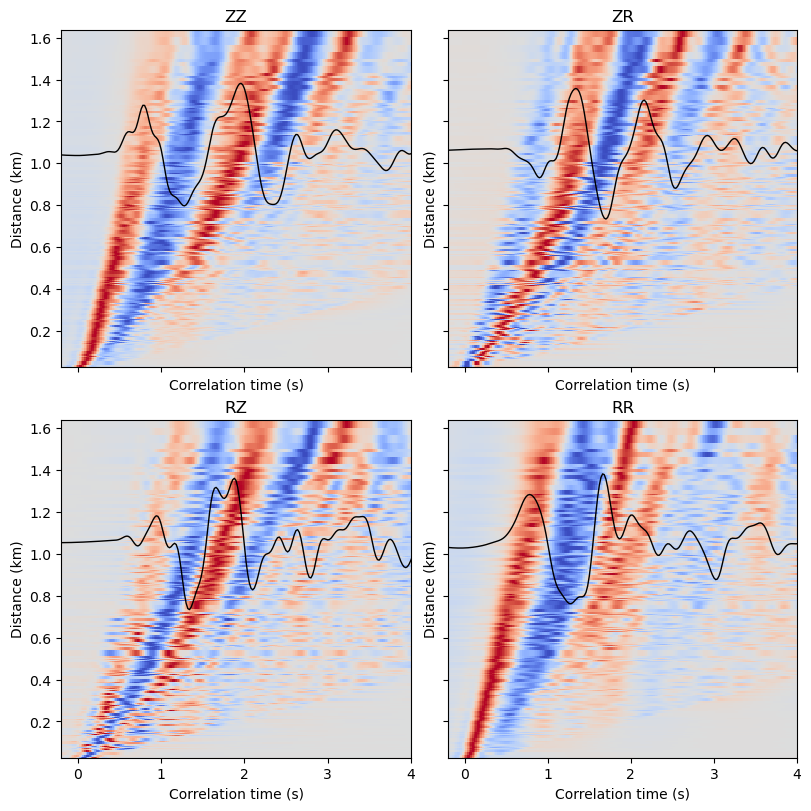

In [15]:
wavefields = {}
wavefield_cache_status = {}
for component in COMPONENTS:
    cache_path = PROCESSED_DIR / f"{component.lower()}_wavefield.npz"
    cache_hit = cache_path.exists()
    if cache_hit:
        # 统一从缓存恢复，确保四个分量不会重复读取。
        wavefields[component] = Wavefield.load(cache_path)
    else:
        # 四个分量分别读取和预处理，但必须保持相同几何元数据。
        wavefields[component] = read_sac_directory(SAC_DIR / component).preprocess()
        wavefields[component].save(cache_path, overwrite=True)
    wavefield_cache_status[component] = "cache hit" if cache_hit else "read and preprocessed"
    print_wavefield_summary(
        f"RR Array / {component}",
        wavefields[component],
        wavefield_cache_status[component],
    )

wfd_zz, wfd_zr, wfd_rz, wfd_rr = (wavefields[component] for component in COMPONENTS)
reference_wavefield = wavefields[COMPONENTS[0]]
for component in COMPONENTS[1:]:
    current = wavefields[component]
    if (
        current.pairs != reference_wavefield.pairs
        or current.n_samples != reference_wavefield.n_samples
        or not np.isclose(current.delta, reference_wavefield.delta)
        or not np.allclose(current.distances, reference_wavefield.distances)
    ):
        raise ValueError(f"{component} 与 {COMPONENTS[0]} 的波场几何不一致。")
print("四个 ANC 分量的台站对、采样和距离元数据一致。")

fig_wavefield, axes = plt.subplots(
    2, 2,
    figsize=(8, 8.),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)
for ax, component in zip(axes.ravel(), COMPONENTS):
    wavefields[component].plot(ax=ax, tshow_min=-0.2, tshow_max=4.0, example_pair=EXAMPLE_PAIR)
    ax.set_title(component)
plt.show()


## 5. Step 2：MASW 识别多模态频散能量
这里同时比较四个分量的频散图。连续的能量带可作为后续极化和相位匹配的质量控制，不应只依据单个亮点判定模态。

[RR Array / ZZ MASW] grid=(1800, 231); frequency=0.502..4.999 Hz; velocity=0.200..2.500 km/s
  strongest normalized energy: f=0.502 Hz, v=2.500 km/s
[RR Array / ZR MASW] grid=(1800, 231); frequency=0.502..4.999 Hz; velocity=0.200..2.500 km/s
  strongest normalized energy: f=0.502 Hz, v=0.710 km/s
[RR Array / RZ MASW] grid=(1800, 231); frequency=0.502..4.999 Hz; velocity=0.200..2.500 km/s
  strongest normalized energy: f=0.502 Hz, v=0.580 km/s
[RR Array / RR MASW] grid=(1800, 231); frequency=0.502..4.999 Hz; velocity=0.200..2.500 km/s
  strongest normalized energy: f=0.502 Hz, v=1.850 km/s


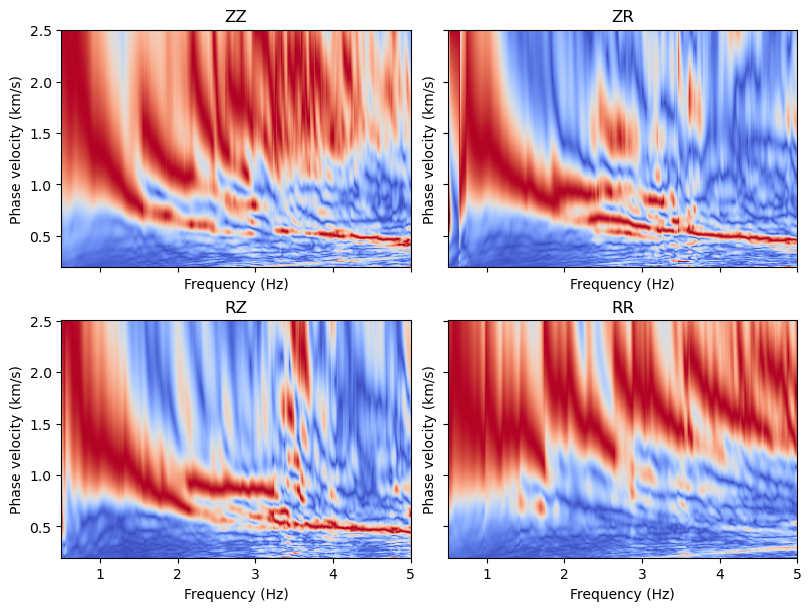

In [16]:

masw_results = {}
masw_cache_status = {}
for component in COMPONENTS:
    cache_path = PROCESSED_DIR / f"{component.lower()}_masw.npz"
    cache_hit = cache_path.exists()
    if cache_hit:
        # 从缓存读取已计算的频散能量图。
        masw_results[component] = MASW.load(cache_path)
    else:
        # 每个分量独立计算 MASW，再比较频散能量的一致性。
        masw_results[component] = MASW(wavefields[component]).compute()
        masw_results[component].save(cache_path, overwrite=True)
    masw_cache_status[component] = "cache hit" if cache_hit else "computed"
    print_masw_summary(
        f"RR Array / {component} MASW",
        masw_results[component],
    )

masw_zz, masw_zr, masw_rz, masw_rr = (
    masw_results[component] for component in COMPONENTS
)

fig_dispersion, axes = plt.subplots(
    2, 2,
    figsize=(8, 6),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)
for ax, component in zip(axes.ravel(), COMPONENTS):
    masw_results[component].plot(ax=ax)
    ax.set_title(component)
plt.show()

## 6. Step 3：极化分离生成 M0 与 M1 候选
在本案例的坐标、径向方向和相关顺序约定下，基阶瑞利波主要表现为逆进运动，第一高阶瑞利波主要表现为顺进运动。交叉分量先经 Hilbert 变换补偿约 90 度相位差，再进行线性组合。

对每个台站对独立进行 RMS 归一化后，本案例使用：

$$
C_{\mathrm{M0,candidate}} =
\frac{\widehat C_{ZZ}
-H(\widehat C_{ZR})
+H(\widehat C_{RZ})
+\widehat C_{RR}}{4},
$$

$$
C_{\mathrm{M1,candidate}} =
\frac{\widehat C_{ZZ}
+H(\widehat C_{ZR})
-H(\widehat C_{RZ})
+\widehat C_{RR}}{4}.
$$

本 notebook 将 `retrograde` 候选映射为 M0，将 `prograde` 候选映射为 M1。这个命名是本案例坐标和相关顺序约定下的标签，使用其他数据时应先重新确认极化方向。

[RR Array / retrograde (M0 candidate)] computed; pairs=253, stations=23 (001-047), samples=4001
  sampling: delta=0.020000 s, rate=50.000 Hz; time=-40.000..40.000 s
  distances: 0.0273..1.6200 km
[RR Array / prograde (M1 candidate)] computed; pairs=253, stations=23 (001-047), samples=4001
  sampling: delta=0.020000 s, rate=50.000 Hz; time=-40.000..40.000 s
  distances: 0.0273..1.6200 km
[RR Array / retrograde MASW] grid=(1800, 231); frequency=0.502..4.999 Hz; velocity=0.200..2.500 km/s
  strongest normalized energy: f=0.502 Hz, v=1.930 km/s
[RR Array / prograde MASW] grid=(1800, 231); frequency=0.502..4.999 Hz; velocity=0.200..2.500 km/s
  strongest normalized energy: f=0.502 Hz, v=2.160 km/s
极化分离完成：retrograde 将作为 M0，prograde 将作为 M1 的参考输入。


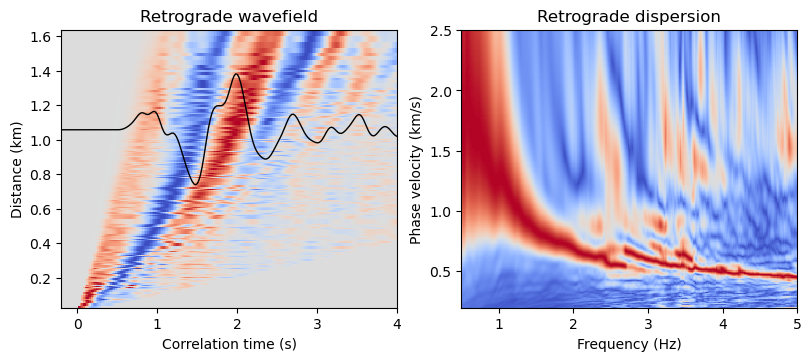

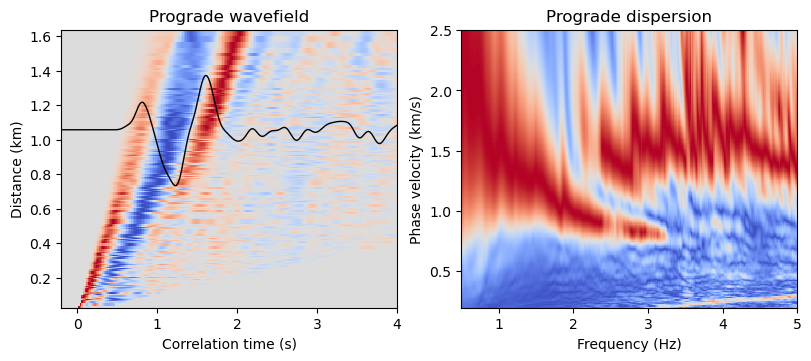

In [17]:
# 交叉分量的 Hilbert 相位补偿和 RMS 归一化由 polarization_separate 完成。
# 在本案例约定下，retrograde -> M0，prograde -> M1。
polarization_separated = polarization_separate(
    zz=wfd_zz,
    rz=wfd_rz,
    zr=wfd_zr,
    rr=wfd_rr,
    use_rr=True,
)

wfd_retrograde = polarization_separated["retrograde"]
wfd_prograde = polarization_separated["prograde"]
masw_retrograde = MASW(wfd_retrograde).compute(n_jobs=8)
masw_prograde = MASW(wfd_prograde).compute(n_jobs=8)
print_wavefield_summary("RR Array / retrograde (M0 candidate)", wfd_retrograde, "computed")
print_wavefield_summary("RR Array / prograde (M1 candidate)", wfd_prograde, "computed")
print_masw_summary("RR Array / retrograde MASW", masw_retrograde)
print_masw_summary("RR Array / prograde MASW", masw_prograde)
print("极化分离完成：retrograde 将作为 M0，prograde 将作为 M1 的参考输入。")

masw_retrograde.save(PROCESSED_DIR / f"retrograde_masw.npz", overwrite=True)
masw_prograde.save(PROCESSED_DIR / f"prograde_masw.npz", overwrite=True)

for mode, wavefield, masw in (
    ("Retrograde", wfd_retrograde, masw_retrograde),
    ("Prograde", wfd_prograde, masw_prograde),
):
    fig, axes = plt.subplots(
        1, 2,
        figsize=(8, 3.5),
        constrained_layout=True,
    )
    wavefield.plot(ax=axes[0], tshow_min=-0.2, tshow_max=4.0, example_pair=EXAMPLE_PAIR)
    masw.plot(ax=axes[1])
    axes[0].set_title(f"{mode} wavefield")
    axes[1].set_title(f"{mode} dispersion")
    plt.show()

## 7. Step 4：选择参考频散曲线输入方式

下面提供两种互斥的操作方式，请只运行其中一种，然后运行最后的共享处理与绘图单元：

- **方案 A：GUI 拾取**：需要本地图形界面和 PyQt5。在 M0、M1 的频散图上左键拾取点，按 Enter 结束。
- **方案 B：直接传入点**：不需要 GUI，将你提供的 `[frequency_Hz, phase_velocity_km_s]` 点分别填入 M0 和 M1 列表。

两种方案最终都生成同名的 `M0_REFERENCE_CURVE` 和 `M1_REFERENCE_CURVE` 变量，后续相位匹配和绘图完全相同。

GUI 方案适合能看到频散图的本地环境；直接输入方案适合无 GUI、远程服务器的用户。点的列顺序必须是 `[frequency_Hz, phase_velocity_km_s]`，频率严格递增且至少提供两个点。

In [18]:
# 方案 A：需要本地 GUI；取消下一行注释后，在当前单元中执行拾取。
# 左键逐点拾取，按 Enter 返回；不要同时运行方案 B 的输入单元。
%matplotlib qt

_, M0_REFERENCE_CURVE = phase_match_separate(
    wfd_retrograde,
    masw_cache_path=PROCESSED_DIR / "retrograde_masw.npz",
    return_reference=True,
)
_, M1_REFERENCE_CURVE = phase_match_separate(
    wfd_prograde,
    masw_cache_path=PROCESSED_DIR / "prograde_masw.npz",
    return_reference=True,
)

# 把 GUI 返回的点打印出来，复制到方案 B 单元即可复用。
print("M0_REFERENCE_CURVE = [")
for frequency, velocity in M0_REFERENCE_CURVE:
    print(f"    [{frequency:.6f}, {velocity:.6f}],")
print("]")
print("M1_REFERENCE_CURVE = [")
for frequency, velocity in M1_REFERENCE_CURVE:
    print(f"    [{frequency:.6f}, {velocity:.6f}],")
print("]")


M0_REFERENCE_CURVE = [
    [1.281172, 2.396250],
    [1.353734, 2.077500],
    [1.517000, 1.577500],
    [1.725617, 1.171250],
    [2.160992, 0.933750],
    [2.678000, 0.815000],
    [3.104305, 0.708750],
    [3.439906, 0.658750],
    [4.274375, 0.590000],
    [4.863945, 0.552500],
]
M1_REFERENCE_CURVE = [
    [1.662125, 2.421250],
    [1.707476, 2.152500],
    [1.879812, 1.771250],
    [2.088430, 1.408750],
    [2.532875, 1.133750],
    [3.176867, 0.977500],
    [3.902492, 0.827500],
    [4.673469, 0.771250],
]


In [ ]:
# 方案 B：直接传入参考频散点；此单元不需要 GUI。
# 将你提供的点分别填入 M0 和 M1 列表，单位为 [frequency_Hz, phase_velocity_km_s]。
# M0_REFERENCE_CURVE = [
#     [1.272101, 2.315000],
#     [1.417226, 1.902500],
#     [1.643984, 1.415000],
#     [2.070289, 1.108750],
#     [2.278906, 0.965000],
#     [2.505664, 0.858750],
#     [2.941039, 0.727500],
#     [3.321992, 0.646250],
#     [3.702945, 0.608750],
#     [4.773242, 0.533750],
# ]
# M1_REFERENCE_CURVE = [
#     [1.662125, 2.365000],
#     [1.961445, 1.777500],
#     [2.142851, 1.390000],
#     [2.523805, 1.146250],
#     [2.913828, 1.015000],
#     [3.594101, 0.833750],
#     [4.609977, 0.771250],
# ]
# if len(M0_REFERENCE_CURVE) < 2 or len(M1_REFERENCE_CURVE) < 2:
#     raise ValueError(
#         "方案 B 需要分别为 M0 和 M1 提供至少两个 [频率, 相速度] 点。"
#     )
# print_reference_curve_summary("M0 reference", M0_REFERENCE_CURVE)
# print_reference_curve_summary("M1 reference", M1_REFERENCE_CURVE)

[M0 reference] points=10; frequency=1.272..4.773 Hz; velocity=0.534..2.315 km/s
[M1 reference] points=7; frequency=1.662..4.610 Hz; velocity=0.771..2.365 km/s


[M0 reference] points=10; frequency=1.281..4.864 Hz; velocity=0.552..2.396 km/s
[M1 reference] points=8; frequency=1.662..4.673 Hz; velocity=0.771..2.421 km/s
[RR Array / M0 separated] phase matched; pairs=253, stations=23 (001-047), samples=4001
  sampling: delta=0.020000 s, rate=50.000 Hz; time=-40.000..40.000 s
  distances: 0.0273..1.6200 km
[RR Array / M1 separated] phase matched; pairs=253, stations=23 (001-047), samples=4001
  sampling: delta=0.020000 s, rate=50.000 Hz; time=-40.000..40.000 s
  distances: 0.0273..1.6200 km
[RR Array / M0 separated MASW] grid=(1800, 231); frequency=0.502..4.999 Hz; velocity=0.200..2.500 km/s
  strongest normalized energy: f=0.502 Hz, v=1.710 km/s
[RR Array / M1 separated MASW] grid=(1800, 231); frequency=0.502..4.999 Hz; velocity=0.200..2.500 km/s
  strongest normalized energy: f=0.502 Hz, v=1.850 km/s


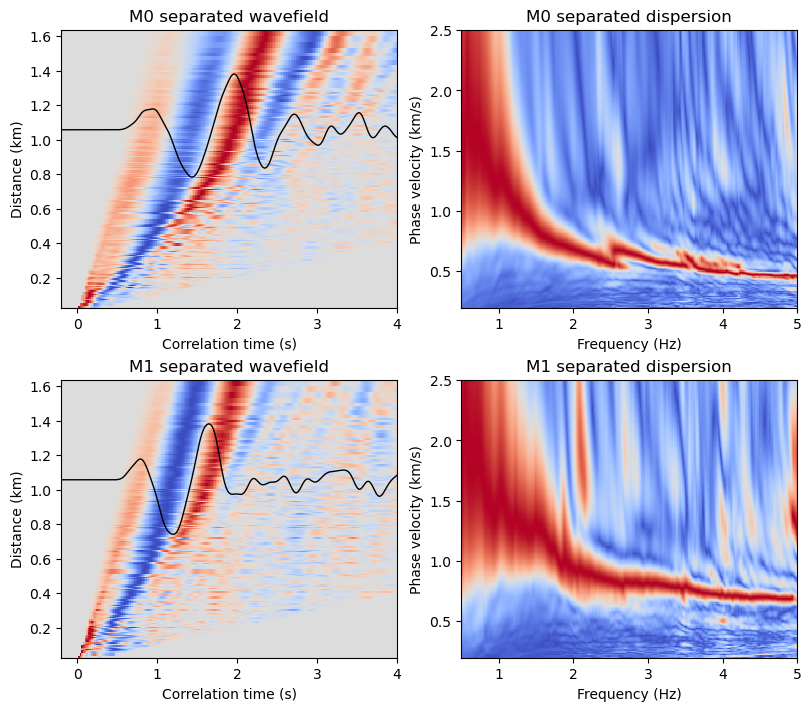

In [19]:
# 共享操作：无论选择方案 A 还是方案 B，都只运行此单元一次。
# phase_match_separate 用参考相速度曲线做频率相关相位校正和速度窗 taper。
%matplotlib inline
wfd_m0_separated = phase_match_separate(
    wfd_retrograde,
    reference_curve=M0_REFERENCE_CURVE,
)
wfd_m1_separated = phase_match_separate(
    wfd_prograde,
    reference_curve=M1_REFERENCE_CURVE,
)
masw_m0_separated = MASW(wfd_m0_separated).compute()
masw_m1_separated = MASW(wfd_m1_separated).compute()
print_reference_curve_summary("M0 reference", M0_REFERENCE_CURVE)
print_reference_curve_summary("M1 reference", M1_REFERENCE_CURVE)
print_wavefield_summary("RR Array / M0 separated", wfd_m0_separated, "phase matched")
print_wavefield_summary("RR Array / M1 separated", wfd_m1_separated, "phase matched")
print_masw_summary("RR Array / M0 separated MASW", masw_m0_separated)
print_masw_summary("RR Array / M1 separated MASW", masw_m1_separated)

fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 7),
    constrained_layout=True,
)
for row, (mode, wavefield, masw) in enumerate((
    ("M0", wfd_m0_separated, masw_m0_separated),
    ("M1", wfd_m1_separated, masw_m1_separated),
)):
    wavefield.plot(
        ax=axes[row, 0],
        tshow_min=-0.2,
        tshow_max=4.0,
        example_pair=EXAMPLE_PAIR,
    )
    masw.plot(ax=axes[row, 1])
    axes[row, 0].set_title(f"{mode} separated wavefield")
    axes[row, 1].set_title(f"{mode} separated dispersion")
plt.show()


## 8. Step 5：分模态 TSI 诊断
M0 与 M1 分别诊断，目的是检查相位匹配是否保留了各自目标模态的走时关系；如果某一模态的诊断图不稳定，应先回到参考曲线或极化分离步骤。

诊断台站对：010-040, distance=1.0578 km; periods=(0.8, 0.3) s


(<Figure size 1000x850 with 8 Axes>,
 array([[<Axes: title={'center': 'Virtual shot gather at station 010'}, ylabel='Station number'>,
         <Axes: title={'center': 'Virtual shot gather at station 040'}>,
         <Axes: title={'center': 'Three-station interferometry'}>],
        [<Axes: xlabel='Correlation time (s)', ylabel='Station number'>,
         <Axes: xlabel='Correlation time (s)'>,
         <Axes: xlabel='Correlation time (s)'>]], dtype=object))

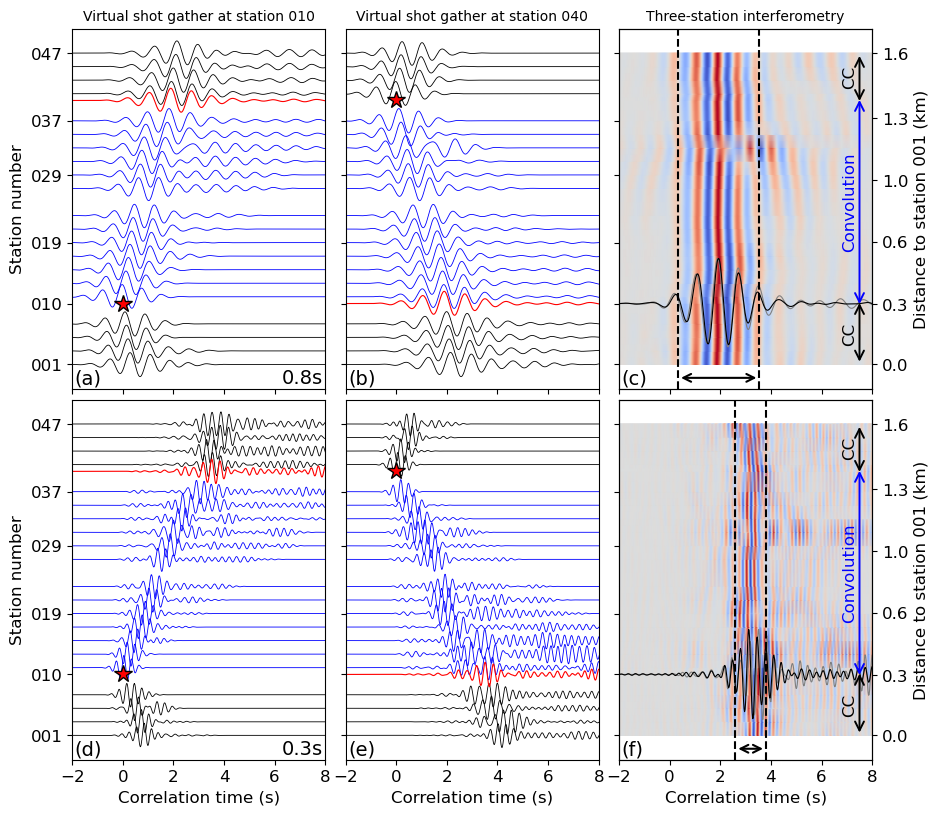

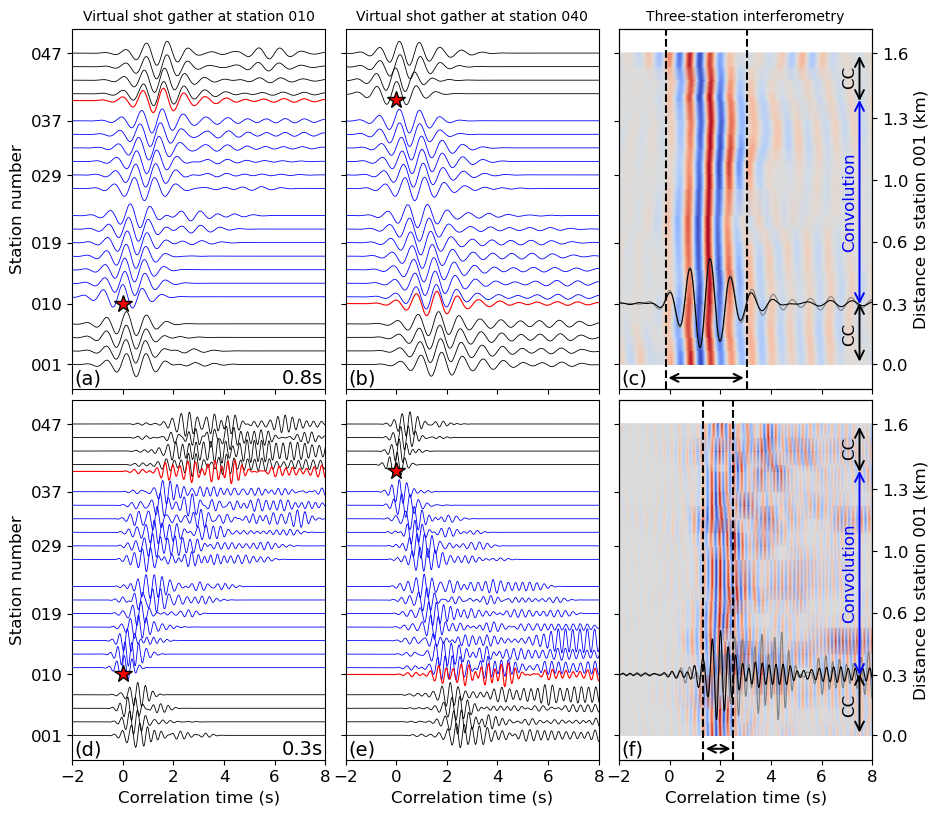

In [23]:
pair_index = wfd_m0_separated.pairs.index(EXAMPLE_PAIR)
pair_distance = wfd_m0_separated.distances[pair_index]
print(
    f"诊断台站对：{EXAMPLE_PAIR[0]}-{EXAMPLE_PAIR[1]}, "
    f"distance={pair_distance:.4f} km; periods={EXAMPLE_PERIODS} s"
)
# M0/M1 分别运行同一诊断接口，便于比较模态差异。
denoise_station_pair_demo(
    wfd_m0_separated,
    EXAMPLE_PAIR,
    periods=EXAMPLE_PERIODS,
)
denoise_station_pair_demo(
    wfd_m1_separated,
    EXAMPLE_PAIR,
    periods=EXAMPLE_PERIODS,
)

## 9. Step 6：分别迭代去噪 M0 与 M1
两个模态使用相同的 TSI 参数和代表性台站对，但生成独立的缓存和收敛记录。比较 `iterations`、`relative_changes`、`converged` 和 `stop_reason`，再解释最终图。

Loaded cached M0_Denoised denoising result.
[M0_Denoised] iterations=3, converged=True, stop_reason=threshold
  relative changes: [0.5421, 0.1583, 0.0388]
  files: M0_Denoised_wavefield.npz, M0_Denoised_info.npz
Loaded cached M1_Denoised denoising result.
[M1_Denoised] iterations=4, converged=True, stop_reason=threshold
  relative changes: [0.7428, 0.2167, 0.0635, 0.0246]
  files: M1_Denoised_wavefield.npz, M1_Denoised_info.npz
输出目录：processed


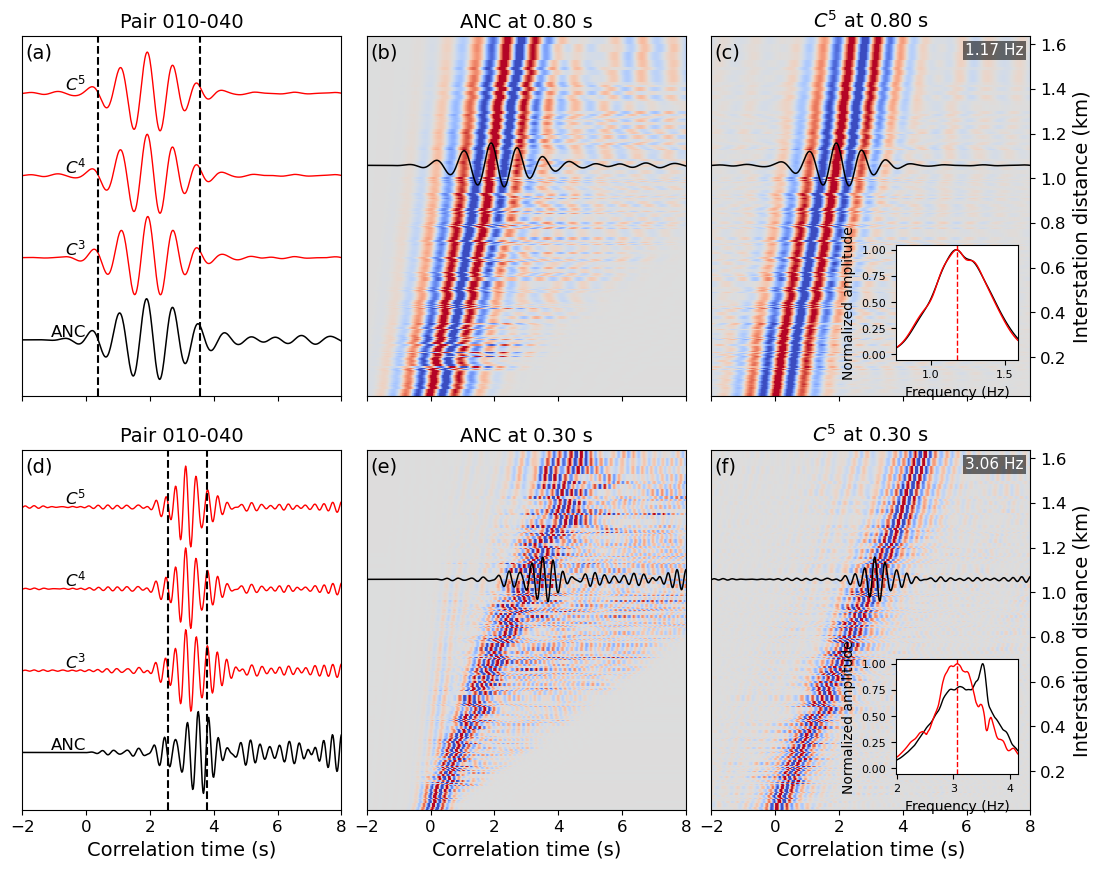

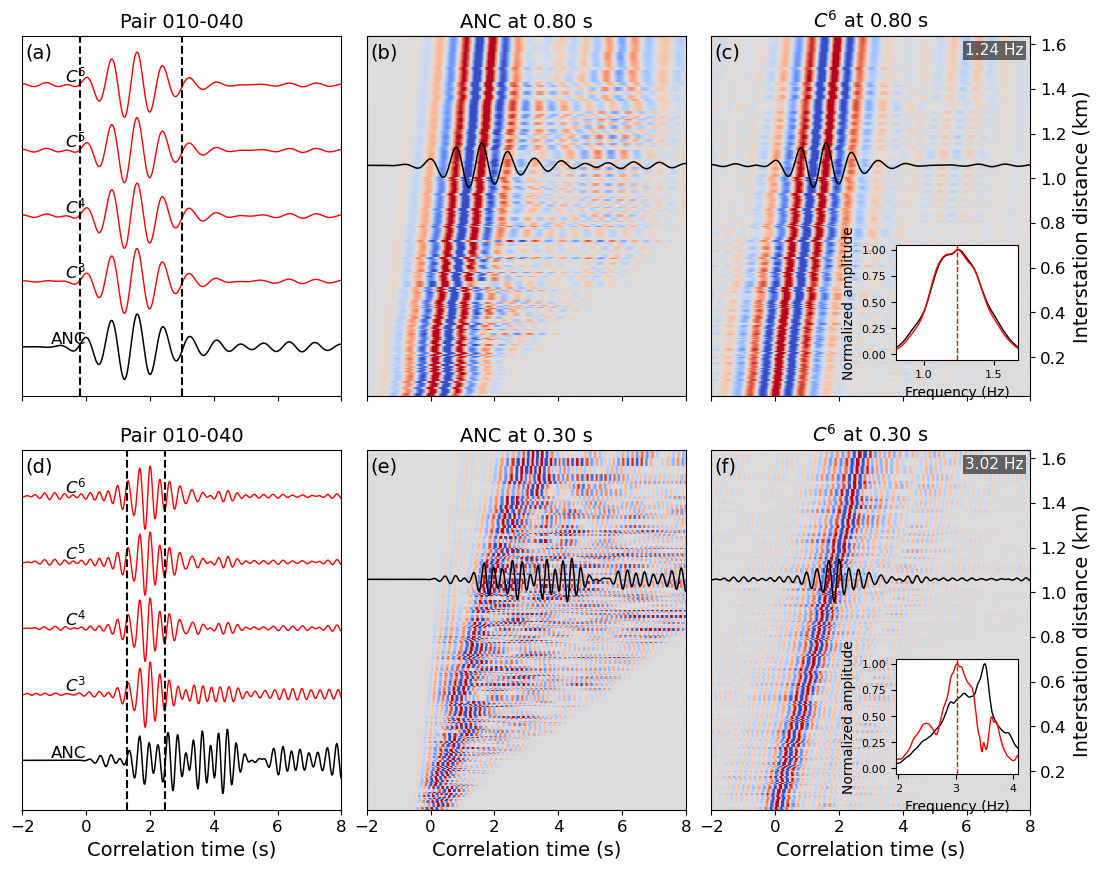

In [24]:

def load_or_denoise(wavefield, result_name):
    """Load a complete result or compute and persist it."""
    result_stem = PROCESSED_DIR / result_name
    wavefield_file = PROCESSED_DIR / f"{result_name}_wavefield.npz"
    info_file = PROCESSED_DIR / f"{result_name}_info.npz"

    if wavefield_file.exists() and info_file.exists():
        # 两个伴随文件都存在才认为缓存完整，避免读取半成品。
        result = DenoisingResult.load(result_stem)
        print(f"Loaded cached {result_name} denoising result.")
    else:
        # threshold 是相邻迭代的相对变化阈值；max_iterations 是安全上限。
        result = denoise_wavefield_iteratively(
            wavefield,
            EXAMPLE_PAIR,
            threshold=0.05,
            first_iteration_convolution=True,
            max_iterations=6,
            taper_output=False,
            n_jobs=8,
        )
        result.save(
            result_stem,
            overwrite=wavefield_file.exists() or info_file.exists(),
        )
        print(f"Computed and saved {result_name} denoising result.")
    print_denoising_summary(result_name, result)
    print(f"  files: {wavefield_file.name}, {info_file.name}")

    return result


m0_denoised_result = load_or_denoise(wfd_m0_separated, "M0_Denoised")
m1_denoised_result = load_or_denoise(wfd_m1_separated, "M1_Denoised")
print(f"输出目录：{PROCESSED_DIR}")

plot_denoised_result(
    wfd_m0_separated,
    m0_denoised_result,
    periods=EXAMPLE_PERIODS,
)
plot_denoised_result(
    wfd_m1_separated,
    m1_denoised_result,
    periods=EXAMPLE_PERIODS,
)
plt.show()

最终波场：M0 pairs=253, M1 pairs=253; samples=4001


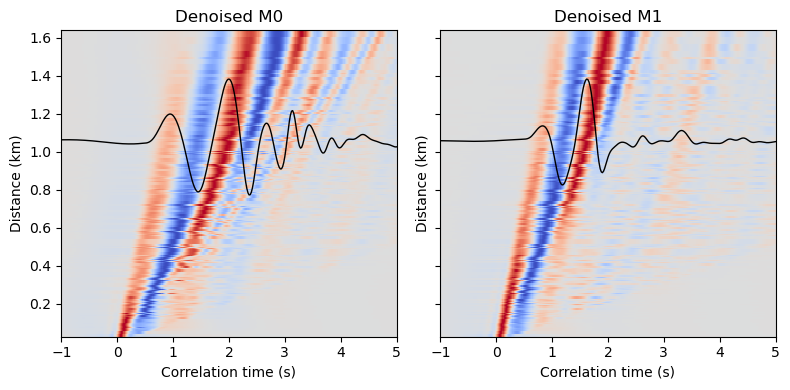

In [25]:
# 最终图只比较空间波场；收敛信息已在上一个单元打印。
denoised_wavefield_m0 = Wavefield.load(PROCESSED_DIR / "M0_Denoised_wavefield.npz").preprocess()
denoised_wavefield_m1 = Wavefield.load(PROCESSED_DIR / "M1_Denoised_wavefield.npz").preprocess()
print(
    f"最终波场：M0 pairs={denoised_wavefield_m0.n_pairs}, M1 pairs={denoised_wavefield_m1.n_pairs}; "
    f"samples={denoised_wavefield_m0.n_samples}"
)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

denoised_wavefield_m0.plot(
    ax=axes[0],
    example_pair=EXAMPLE_PAIR,
    tshow_max=5,
    tshow_min=-1,
)
axes[0].set_title("Denoised M0")

denoised_wavefield_m1.plot(
    ax=axes[1],
    example_pair=EXAMPLE_PAIR,
    tshow_max=5,
    tshow_min=-1,
)
axes[1].set_title("Denoised M1")

plt.tight_layout()
plt.show()